# __Dados e Métricas__

## __Motivação__

O nosso objetivo era construir um estudo sobre o perfil de clubes, representado as dinâmicas do mercado futebolístico de atletas em um grafo direcional, calculando métricas relevantes para identificar possíveis padrões.  

## __Dados__

Como fonte de dados optamos pelos registros do site da ESPN, que foram coletados através de um _"web scrapping manual"_. Depois de tratar todas as informações que precisavamos para  construção de uma API usando o Sheety.

_A célula de código abaixo coleta os dados de nossa API._

In [1]:
from src.graph import get_env_variable, get_api_page

api_url = get_env_variable("API_URL")
page = get_api_page(api_url, "transfers")

## __O Grafo__

Para construir nosso grafo, tomamos como vértices cada um dos 312 times de futebol, mais um vértice especial que serviria para representar as transferências que vem de fora do cenário profissional __"sem-time"__.

Já para as arestas, durante os primeiros testes da modelagem, observamos que em alguns casos, múltiplas transferências são registradas num mesmo sentido, poderíamos usar um multigrafo, que consideraria cada um desses casos como uma aresta a parte, ou poderíamos usar um grafo direcional simples, por um lado, tornamos nosso trabalho muito penoso sem grandes ganhos reais, por outro lado possívelmente perderíamos informações relevantes, o que poderia prejudicar nossa análise.

##### _Como conciliar ambos?_
Realizando algumas pesquisas sobre as ferramentas a nossa disposição, encontramos uma resposta, a biblioteca __NetworkX__ permite que suas instâncias recebam objetos de qualquer tipo, para além disso, o __Python__ também oferece um recuroso no uso de funções chamado __**kwargs__, que associa valores a chaves. Esses valores podem ser acessados posteriormente usando essas mesmas chaves, a partir de uma instância do objeto, - no caso a partir de uma aresta.

Sabendo disso, optamos por um grafo simples direcional, no qual as arestas não representariam as transferências em si, mas os sentidos no qual essas ocorrem. Para que isso fosse possível sem perdas, as arestas de nosso grafo receberam dois novos atributos, o primeiro, seria responsável por armazenar uma lista de dicionários, cada um contendo informações sobre as transferências que ocorrem naquele sentido, já o segundo, armazenaria a quantidade de transferências que ocorrem naquele sentido, permitindo fácil acesso a esses dados.Entretanto existe um problema nesta definição para as arestas.

##### _Como representar essa maior tendência de movimento para que se possa gerar dados mais condizentes com a realidade, tendo em vista os valores vinculados aos menores caminhos de nosso grafo?_
A melhor escolha que tomamos foi a de definir o peso das arestas através da fórmula  $ 1/x $, onde $ x $ representa a quantidade de transferências ocorridas naquele sentido, deste modo, o peso das arestas diminuí de maneira inversamente proporcional a quantidade de transferências registradas nela, aproximando nosso modelo da realidade.

_As células abaixo geram nosso grafo e um __spring layout__, em seguida fazem a plotagem do grafo usando o próprio layout._ 

In [2]:
from src.graph import build_di_graph

graph, layout = build_di_graph(page, "from", "to")

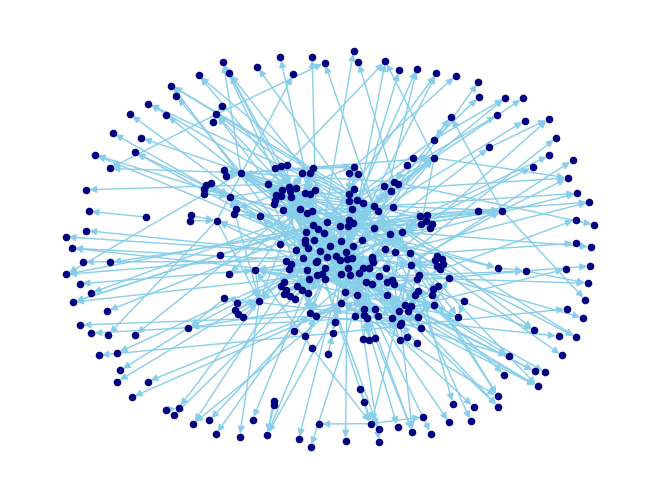

In [3]:
from src.visualization import draw_di_graph
from matplotlib import pyplot

draw_di_graph(pyplot, graph, layout)